# MSA 2026 Phase 2 - Part 3: Data Analysis Project

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define global plotting design

plt.rcParams.update({

    # Figure
    "figure.figsize": (8, 6),
    "figure.dpi": 120,

    # Font
    "font.family": "DejaVu Sans",

    # Title
    "axes.titlesize": 18,
    "axes.titleweight": "bold",

    # Axis labels
    "axes.labelsize": 14,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 13,

    # Grid
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Axes
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Save figures
    "savefig.bbox": "tight"

})

# color dicts
PRIMARY = "#4E79A7"      # Tableau Blue
SECONDARY = "#C06C84"    # Dusty Rose
ACCENT = "#6C5B7B"       # Purple
GREEN = "#2A9D8F"
ORANGE = "#F28E2B"    # Tableau Orange

## 1. Load and check the dataset

In [3]:
# Load weather data from the csv file
sales_data = pd.read_csv('Sales Data.csv')
sales_data.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


### 1.1 Examine Data types and missing values

In [4]:
# Check data types and missing values
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  str    
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  str    
 6   Purchase Address  185950 non-null  str    
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  str    
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 15.6 MB


* **Observation**: There are 185950 records and 11 variables. No missing value is found.

### 1.2 Investigate duplicate records

In [5]:
# Check duplicates
duplicates = sales_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


### 1.3 Check unnamed column

In [6]:
# Check if column 'Unnamed' is data index
(sales_data["Unnamed: 0"] == sales_data.index).all()

np.False_

In [7]:
# Check data distribution of the column
sales_data[["Unnamed: 0"]].describe()

,Unnamed: 0
count,185950.000000
mean,8340.388475
std,5450.554093
min,0.000000
25%,3894.000000
50%,7786.000000
75%,11872.000000
max,25116.000000


* **Observation:** Based on the destribution of the values, the Unnamed column may consist of non-consecutive integer numbers and/or there are duplicated records.

In [8]:
# Check unique value of the column and if there are duplicates
sales_data['Unnamed: 0'].unique()

array([    0,     1,     2, ..., 20134, 20172, 20318], shape=(25093,))

In [9]:
duplicated_unnamed = sales_data["Unnamed: 0"].value_counts()[lambda x: x > 1]
duplicated_unnamed

Unnamed: 0
0        12
2        12
3        12
4        12
5        12
         ..
20377     2
20378     2
17726     2
17960     2
18062     2
Name: count, Length: 20358, dtype: int64

In [10]:
# Randomly select one duplicate to examine
# sales_data[sales_data["Unnamed: 0"] == 0] # one record for each month
sales_data[sales_data["Unnamed: 0"] == 20377]

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
20273,20377,315135,Wired Headphones,1,11.99,2019-12-12 16:22:00,"245 Sunset St, Los Angeles, CA 90001",12,11.99,Los Angeles,16
136791,20377,278795,iPhone,1,700.00,2019-10-31 17:21:00,"291 Hill St, Seattle, WA 98101",10,700.00,Seattle,17


In [11]:
# check time range of the data
sales_data['Order Date'] = sales_data['Order Date'].apply(pd.to_datetime)
print('Data covers from {} to {}'.format(sales_data['Order Date'].min(), sales_data['Order Date'].max()))

Data covers from 2019-01-01 03:07:00 to 2020-01-01 05:13:00


* **Conclusion:** Since the dataset contains only one-year records of the sales data, and maximum duplicates of the Unnamed column is 12 rows (one per month), it can be inferred that the Unnamed variable may be original index of the raw data and provides no informative message. Therefore, it should be removed during pre-processing.

## 2. Clean the dataset, drop variables

### 2.1 Correct data types

In [12]:
# Make Order Id string type as this is identifier varibale;
sales_data['Order ID'] = sales_data['Order ID'].astype(str)
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Unnamed: 0        185950 non-null  int64         
 1   Order ID          185950 non-null  str           
 2   Product           185950 non-null  str           
 3   Quantity Ordered  185950 non-null  int64         
 4   Price Each        185950 non-null  float64       
 5   Order Date        185950 non-null  datetime64[us]
 6   Purchase Address  185950 non-null  str           
 7   Month             185950 non-null  int64         
 8   Sales             185950 non-null  float64       
 9   City              185950 non-null  str           
 10  Hour              185950 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(4), str(4)
memory usage: 15.6 MB


### 2.2 Drop Unnamed column

In [13]:
# Drop Unnamed column
sales_data = sales_data.drop(columns=["Unnamed: 0"])
sales_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


### 2.3 Check data distribution and outliers

In [14]:
sales_data.describe()

,Quantity Ordered,Price Each,Order Date,Month,Sales,Hour
count,185950.000000,185950.000000,185950,185950.000000,185950.000000,185950.000000
mean,1.124383,184.399735,2019-07-18 21:54:38.887550,7.059140,185.490917,14.413305
min,1.000000,2.990000,2019-01-01 03:07:00,1.000000,2.990000,0.000000
25%,1.000000,11.950000,2019-04-16 21:05:15,4.000000,11.950000,11.000000
50%,1.000000,14.950000,2019-07-17 20:40:30,7.000000,14.950000,15.000000
75%,1.000000,150.000000,2019-10-26 08:14:00,10.000000,150.000000,19.000000
max,9.000000,1700.000000,2020-01-01 05:13:00,12.000000,3400.000000,23.000000
std,0.442793,332.731330,NaN,3.502996,332.919771,5.423416


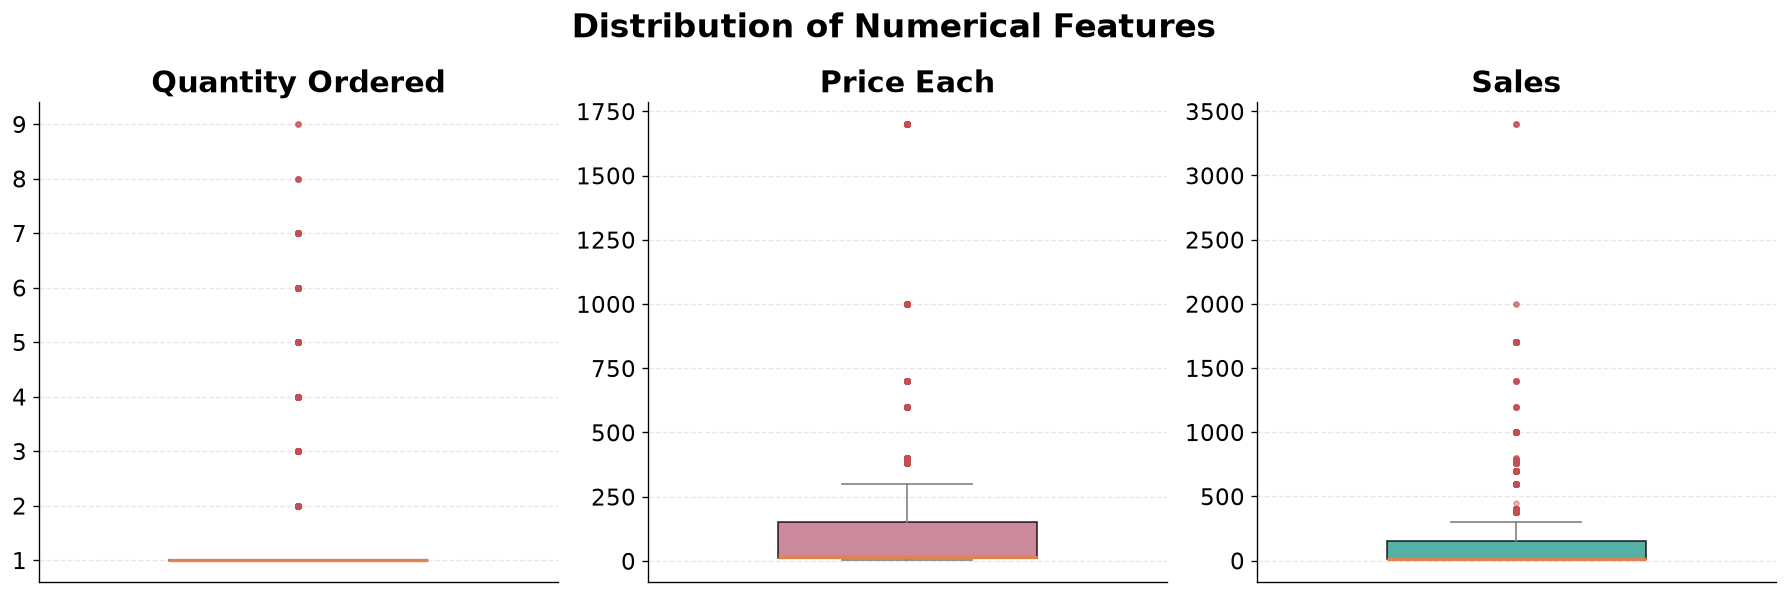

In [15]:
# Visualise with box-plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

numeric_cols = [
    "Quantity Ordered",
    "Price Each",
    "Sales"
]

colors = [
    PRIMARY,
    SECONDARY,
    GREEN
]

for ax, col, color in zip(axes, numeric_cols, colors):

    ax.boxplot(
        sales_data[col],
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=color, alpha=0.8),
        medianprops=dict(color="#DD8452", linewidth=2),
        whiskerprops=dict(color="gray"),
        capprops=dict(color="gray"),
        flierprops=dict(
            marker="o",
            markerfacecolor="#C44E52",
            markeredgecolor="#C44E52",
            markersize=3,
            alpha=0.4
        )
    )

    ax.set_title(col)
    ax.set_xticks([])


plt.suptitle("Distribution of Numerical Features", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.show()

* **Decision:** **Outliers were retained** because they represent valid business transactions rather than data errors. For example, premium electronic products naturally have much higher unit prices and sales values than low-cost accessories. **Feature standardisation will be applied** where appropriate for machine learning models that are sensitive to variable scales.

    Quantity Ordered is highly concentrated at one unit, indicating that most transaction lines involve a single unit of a product.

## 3. Explanatory Analysis

### 3.1 Check data distribution and outliers

In [ ]:
sales_data.describe()

,Quantity Ordered,Price Each,Order Date,Month,Sales,Hour
count,185950.000000,185950.000000,185950,185950.000000,185950.000000,185950.000000
mean,1.124383,184.399735,2019-07-18 21:54:38.887550,7.059140,185.490917,14.413305
min,1.000000,2.990000,2019-01-01 03:07:00,1.000000,2.990000,0.000000
25%,1.000000,11.950000,2019-04-16 21:05:15,4.000000,11.950000,11.000000
50%,1.000000,14.950000,2019-07-17 20:40:30,7.000000,14.950000,15.000000
75%,1.000000,150.000000,2019-10-26 08:14:00,10.000000,150.000000,19.000000
max,9.000000,1700.000000,2020-01-01 05:13:00,12.000000,3400.000000,23.000000
std,0.442793,332.731330,NaN,3.502996,332.919771,5.423416


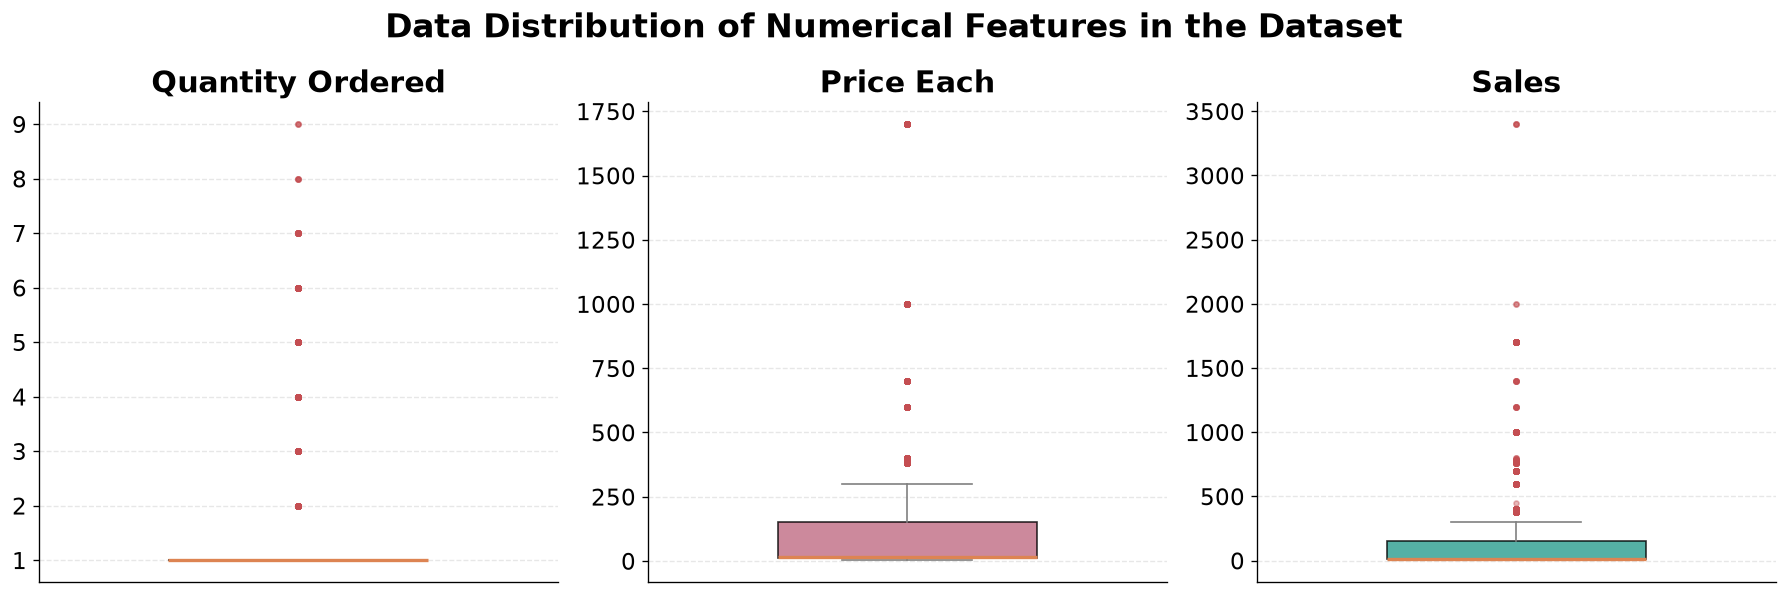

In [61]:
# Visualise with box-plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

numeric_cols = [
    "Quantity Ordered",
    "Price Each",
    "Sales"
]

colors = [
    PRIMARY,
    SECONDARY,
    GREEN
]

for ax, col, color in zip(axes, numeric_cols, colors):

    ax.boxplot(
        sales_data[col],
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=color, alpha=0.8),
        medianprops=dict(color="#DD8452", linewidth=2),
        whiskerprops=dict(color="gray"),
        capprops=dict(color="gray"),
        flierprops=dict(
            marker="o",
            markerfacecolor="#C44E52",
            markeredgecolor="#C44E52",
            markersize=3,
            alpha=0.4
        )
    )

    ax.set_title(col)
    ax.set_xticks([])


plt.suptitle("Data Distribution of Numerical Features in the Dataset", fontsize=20, fontweight="bold")
plt.tight_layout()
plt.savefig("Figures/Figure1_Data Distribution of Numerical Features in the Dataset.jpg")
plt.show()

* **Decision:** **Outliers were retained** because they represent valid business transactions rather than data errors. For example, premium electronic products naturally have much higher unit prices and sales values than low-cost accessories. **Feature standardisation will be applied** where appropriate for machine learning models that are sensitive to variable scales.

    Quantity Ordered is highly concentrated at one unit, indicating that most transaction lines involve a single unit of a product.

### 3.2 Which month generates the highest revenue?

In [16]:
# Group by month and calculate sales
monthly_sales = (
    sales_data
    .groupby("Month")["Sales"]
    .sum()
)

# Sort by sales value to get the month with the highest revenue
monthly_sales.sort_values(ascending=False)

Month
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Sales, dtype: float64

* **December** is the month generates the highest revenue f 4,613,443.34 USD.

### 3.3 Which city contributes the most sales?

In [17]:
# Group by city and calculate sales
city_sales = (
    sales_data
    .groupby("City")["Sales"]
    .sum()
)

# Sort by sales value to get the city with the highest revenue
city_sales.sort_values(ascending=False)

City
San Francisco    8262203.91
Los Angeles      5452570.80
New York City    4664317.43
Boston           3661642.01
Atlanta          2795498.58
Dallas           2767975.40
Seattle          2747755.48
Portland         2320490.61
Austin           1819581.75
Name: Sales, dtype: float64

* **San Francisco** contributes the most sales of 8,262,203.91 USD.

### 3.4 Which products have the highest quantity sold and revenue contribution?

In [18]:
# Group by product and calculate total quantity sold and total sales
product_sales = (
    sales_data
    .groupby("Product")
    .agg(
        Total_Quantity_Ordered=("Quantity Ordered", "sum"),
        Total_Sales=("Sales", "sum")
    )
    .reset_index()
)
product_sales.head()

,Product,Total_Quantity_Ordered,Total_Sales
0,20in Monitor,4129,454148.71
1,27in 4K Gaming Monitor,6244,2435097.56
2,27in FHD Monitor,7550,1132424.50
3,34in Ultrawide Monitor,6199,2355558.01
4,AA Batteries (4-pack),27635,106118.40


In [19]:
# Sort by total quantity to get the product with the highest quantity
product_sales.sort_values(
    by="Total_Quantity_Ordered",
    ascending=False
).head()

,Product,Total_Quantity_Ordered,Total_Sales
5,AAA Batteries (4-pack),31017,92740.83
4,AA Batteries (4-pack),27635,106118.40
15,USB-C Charging Cable,23975,286501.25
12,Lightning Charging Cable,23217,347094.15
17,Wired Headphones,20557,246478.43


* **AAA Batteries (4-pack)** has the highest quantity sold, with 31,017 Total_Quantity_Ordered.

In [20]:
# Sort by total sales to get the product with the highest revenue
product_sales.sort_values(
    by="Total_Sales",
    ascending=False
).head()

,Product,Total_Quantity_Ordered,Total_Sales
13,Macbook Pro Laptop,4728,8037600.00
18,iPhone,6849,4794300.00
14,ThinkPad Laptop,4130,4129958.70
9,Google Phone,5532,3319200.00
1,27in 4K Gaming Monitor,6244,2435097.56


* **Macbook Pro Laptop** contributed to the revenue most with Total_Sales of 8,037,600 USD. 

### 3.5 What time of day has the highest order activity?

In [21]:
# Group by hour and calculate total order counts
hourly_orders = (
    sales_data
    .groupby("Hour")
    .agg(
        Total_Orders=("Order ID", "nunique")
    )
)

# Sort by Total_Orders to get the Hour with the highest order activity
hourly_orders.sort_values(
    by="Total_Orders",
    ascending=False
).head()

,Total_Orders
Hour,
19,12377
12,12082
11,11882
20,11763
18,11761


* **19:00** shows the highest order activity with order count of 12,377.

### 3.6 Are expensive products sold less frequently?

In [22]:
# Check how many products in the data
product_count = sales_data["Product"].nunique()
print(f"There are {product_count} products in the dataset.")

There are 19 products in the dataset.


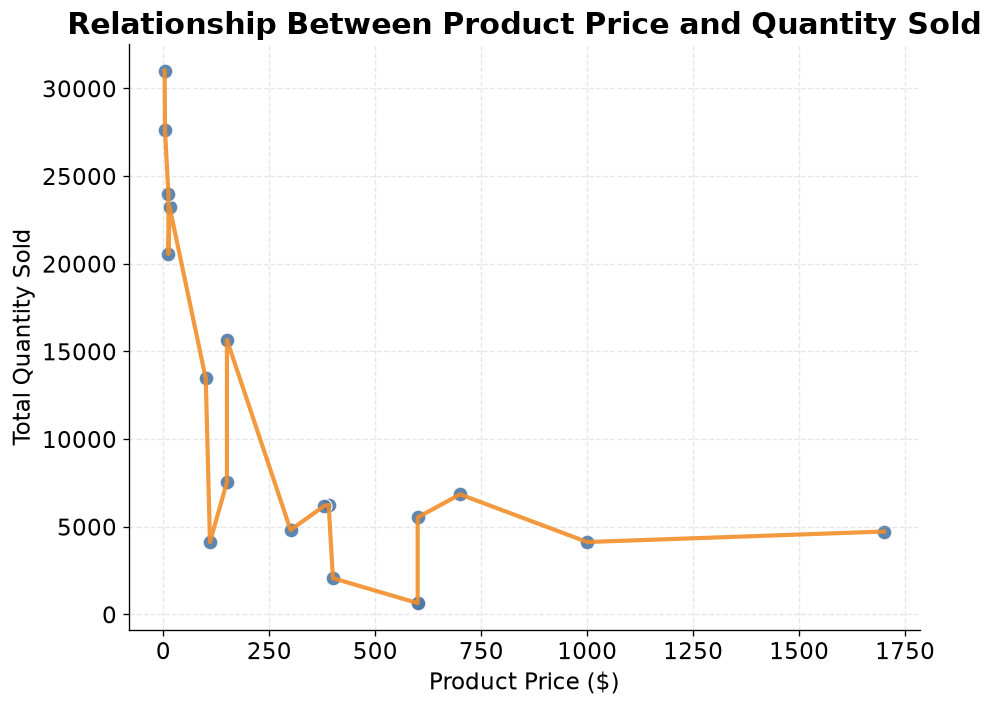

In [23]:
# Check price-quantity relationship by scatter plot
product_summary = (
    sales_data
    .groupby("Product")
    .agg(
        Price=("Price Each", "first"),
        Total_Quantity=("Quantity Ordered", "sum")
    )
)
# Sort products by price before connecting the data points
product_summary_sorted = product_summary.sort_values("Price")

plt.figure()

plt.scatter(
    product_summary["Price"],
    product_summary["Total_Quantity"],
    s=80,
    color= PRIMARY,
    edgecolors="white",
    linewidth=0.8,
    alpha=0.9,
    label="Products"
)

# Connect observations in ascending price order
plt.plot(
    product_summary_sorted["Price"],
    product_summary_sorted["Total_Quantity"],
    color=ORANGE,          
    linewidth=2.5,
    alpha=0.9,
    label="Observed Trend",
    zorder=2
)

plt.xlabel("Product Price ($)")
plt.ylabel("Total Quantity Sold")
plt.title("Relationship Between Product Price and Quantity Sold")
plt.tight_layout()
plt.show()


* The scatter plot suggests an overall negative relationship between product price and total quantity sold. **Lower-priced products generally achieve higher sales volumes**, whereas higher-priced products tend to sell in smaller quantities. Though a few products deviate from this overall pattern, these exceptions likely reflect differences in product category and customer demand rather than contradicting the general trend.

## 4. Association Rule / Market Basket Analysis

### 4.1 Create shopping baskets

In [24]:
# Create baskets containing unique products within each order
shopping_baskets = (
    sales_data
    .groupby("Order ID")["Product"]
    .apply(lambda products: sorted(set(products)))
    .reset_index(name="Products")
)

shopping_baskets.head(10)

,Order ID,Products
0,141234,[iPhone]
1,141235,[Lightning Charging Cable]
2,141236,[Wired Headphones]
3,141237,[27in FHD Monitor]
4,141238,[Wired Headphones]
5,141239,[AAA Batteries (4-pack)]
6,141240,[27in 4K Gaming Monitor]
7,141241,[USB-C Charging Cable]
8,141242,[Bose SoundSport Headphones]
9,141243,[Apple Airpods Headphones]


In [25]:
basket_size_summary = (
    shopping_baskets["Products"]
    .str.len()
    .value_counts()
    .sort_index()
    .rename_axis("Numb_of_Prodt_in_Comb")
    .reset_index(name="Number_of_Orders")
)
# Calculate percentage of total orders
basket_size_summary["Percentage"] = (
    basket_size_summary["Number_of_Orders"]
    / basket_size_summary["Number_of_Orders"].sum()
    * 100
).round(2)

basket_size_summary

,Numb_of_Prodt_in_Comb,Number_of_Orders,Percentage
0,1,171605,96.17
1,2,6479,3.63
2,3,337,0.19
3,4,15,0.01
4,5,1,0.00


* **Observatiion:** The vast majority of orders (96.17%) contained only one product, while **multi-product orders accounted for less than 4% of all transactions.** This indicates that frequent multi-item combinations are relatively rare, suggesting a low minimum support threshold later in the application of Apriori algorithm.

### 4.1 Apply Apriori algorithm

In [26]:
# Install library
# !pip install mlxtend

In [27]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

In [28]:
# Convert shopping baskets into a one-hot encoded transaction matrix
te = TransactionEncoder()

basket_array = te.fit(
    shopping_baskets["Products"]
).transform(
    shopping_baskets["Products"]
)

basket_encoded = pd.DataFrame(
    basket_array,
    columns=te.columns_
)

basket_encoded.head()

,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [29]:
# Trial with different min_support thresholds to get optimal outputs of itemsets
supports = [0.01, 0.005, 0.001, 0.0005, 0.0002, 0.0001]

total_orders = sales_data["Order ID"].nunique()
support_results = []

for s in supports:
    fi = apriori(
        basket_encoded,
        min_support=s,
        use_colnames=True
    )

    itemset_sizes = fi["itemsets"].apply(len)

    support_results.append({
        "Min_Support": s,
        "Min_Orders_Required": int(np.ceil(s * total_orders)),
        "Frequent_Itemsets": len(fi),
        "Multi_Item_Itemsets": (itemset_sizes >= 2).sum()
    })

support_summary = pd.DataFrame(support_results)

print(f"There are totally {total_orders} orders recorded in the dataset.")
support_summary

There are totally 178437 orders recorded in the dataset.


,Min_Support,Min_Orders_Required,Frequent_Itemsets,Multi_Item_Itemsets
0,0.0100,1785,17,0
1,0.0050,893,19,2
2,0.0010,179,27,8
3,0.0005,90,35,16
4,0.0002,36,55,36
5,0.0001,18,96,77


* **Decision:** A minimum support of 0.0005 requires each itemset to occur in at least 90 of the 178,437 orders while retaining 16 multi-item combinations. This help to eliminate chances of random purchasing and provide enough itemsets to study on. Reducing the threshold further to 0.0002 increases the number of multi-item itemsets to 36 but lowers the minimum evidence to only 36 orders. Risk of random purchasing bahaviour cannot be excluded as such. Therefore, **0.0005 was selected as the more conservative threshold.**

In [30]:
# Identify frequent product itemsets
freq_itemsets = apriori(
    basket_encoded,
    min_support=0.0005,
    use_colnames=True
)

freq_itemsets.head(10)

,support,itemsets
0,0.022966,frozenset({20in Monitor})
1,0.034886,frozenset({27in 4K Gaming Monitor})
2,0.042020,frozenset({27in FHD Monitor})
3,0.034600,frozenset({34in Ultrawide Monitor})
4,0.115122,frozenset({AA Batteries (4-pack)})
5,0.115408,frozenset({AAA Batteries (4-pack)})
6,0.087005,frozenset({Apple Airpods Headphones})
7,0.074525,frozenset({Bose SoundSport Headphones})
8,0.026867,frozenset({Flatscreen TV})
9,0.030946,frozenset({Google Phone})


In [31]:
# Count items of each set
freq_itemsets["Item_Count"] = (
    freq_itemsets["itemsets"]
    .apply(len)
)
freq_itemsets.head()

,support,itemsets,Item_Count
0,0.022966,frozenset({20in Monitor}),1
1,0.034886,frozenset({27in 4K Gaming Monitor}),1
2,0.042020,frozenset({27in FHD Monitor}),1
3,0.034600,frozenset({34in Ultrawide Monitor}),1
4,0.115122,frozenset({AA Batteries (4-pack)}),1


In [32]:
# Get item combination >=2
freq_prdt_comb = (
    freq_itemsets[
        freq_itemsets["Item_Count"] >= 2
    ]
    .sort_values(
        by="support",
        ascending=False
    )
)

freq_prdt_comb.head(10)

,support,itemsets,Item_Count
30,0.005666,"frozenset({Lightning Charging Cable, iPhone})",2
26,0.005587,"frozenset({USB-C Charging Cable, Google Phone})",2
34,0.002589,"frozenset({iPhone, Wired Headphones})",2
27,0.002365,"frozenset({Wired Headphones, Google Phone})",2
23,0.002090,"frozenset({iPhone, Apple Airpods Headphones})",2
31,0.002062,"frozenset({Vareebadd Phone, USB-C Charging Cab...",2
24,0.001278,"frozenset({Bose SoundSport Headphones, Google ...",2
32,0.001138,"frozenset({USB-C Charging Cable, Wired Headpho...",2
33,0.000835,"frozenset({Vareebadd Phone, Wired Headphones})",2
29,0.000723,"frozenset({Lightning Charging Cable, Wired Hea...",2


### 4.3 Generate association rules

In [33]:
from mlxtend.frequent_patterns import association_rules

In [34]:
freq_itemsets["itemsets"].apply(len).value_counts()

itemsets
1    19
2    16
Name: count, dtype: int64

In [35]:
# Generate association rules from frequent itemsets
association_results = association_rules(
    freq_itemsets,
    metric="confidence",
    min_threshold=0
)

association_results.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Lightning Charging Cable}),frozenset({AA Batteries (4-pack)}),0.121074,0.115122,0.000594,0.004906,0.042620,1.0,-0.013344,0.889241,-0.962346,0.002521,-0.124554,0.005033
1,frozenset({AA Batteries (4-pack)}),frozenset({Lightning Charging Cable}),0.115122,0.121074,0.000594,0.005160,0.042620,1.0,-0.013344,0.883485,-0.962101,0.002521,-0.131881,0.005033
2,frozenset({AAA Batteries (4-pack)}),frozenset({USB-C Charging Cable}),0.115408,0.122480,0.000532,0.004613,0.037665,1.0,-0.013603,0.881587,-0.966536,0.002243,-0.134318,0.004480
3,frozenset({USB-C Charging Cable}),frozenset({AAA Batteries (4-pack)}),0.122480,0.115408,0.000532,0.004347,0.037665,1.0,-0.013603,0.888454,-0.966795,0.002243,-0.125550,0.004480
4,frozenset({Lightning Charging Cable}),frozenset({Apple Airpods Headphones}),0.121074,0.087005,0.000650,0.005369,0.061713,1.0,-0.009884,0.917923,-0.945350,0.003134,-0.089416,0.006421


In [36]:
# Output result in summary table
association_summary = (
    association_results[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ]
    )

# Convert product name into readable format

association_summary["Antecedent"] = (
    association_summary["antecedents"]
    .apply(lambda x: ", ".join(sorted(x)))
)

association_summary["Consequent"] = (
    association_summary["consequents"]
    .apply(lambda x: ", ".join(sorted(x)))
)

# Rename column names and sort by LIFT score
association_summary = (
    association_summary[
        [
            "Antecedent",
            "Consequent",
            "support",
            "confidence",
            "lift"
        ]
    ]
    .sort_values(
        by="lift",
        ascending=False
    )
    .reset_index(drop=True)
)

In [37]:
# Only display product pairs with LIFT > 1as these represent positive purchasing 
# associations beyond random co-occurrence.
association_summary = (
    association_summary
    .query("lift > 1")
    .sort_values(
        by=["lift", "support"],
        ascending=[False, False]
    )
)
association_summary

,Antecedent,Consequent,support,confidence,lift
0,USB-C Charging Cable,Google Phone,0.005587,0.045619,1.474120
1,Google Phone,USB-C Charging Cable,0.005587,0.180551,1.474120
2,Vareebadd Phone,USB-C Charging Cable,0.002062,0.178208,1.454996
3,USB-C Charging Cable,Vareebadd Phone,0.002062,0.016838,1.454996
4,iPhone,Lightning Charging Cable,0.005666,0.147807,1.220804
5,Lightning Charging Cable,iPhone,0.005666,0.046797,1.220804


* **Summary:** The association rule analysis shows that **charging accessories are the products most frequently purchased together with smartphones.** The most common combinations were USB-C Charging Cable & Google Phone (support = 0.56%, lift = 1.47), Lightning Charging Cable & iPhone (support = 0.57%, lift = 1.22), and USB-C Charging Cable & Vareebadd Phone (support = 0.21%, lift = 1.45). These combinations have lift values greater than 1, indicating that customers were more likely to purchase these products together than would be expected by chance.

    Although the support values are relatively low (below 1%), this is expected because over 96% of orders in the dataset contained only a single product.
    
    Overall, the results suggest that customers commonly purchase compatible charging accessories together with smartphones, highlighting a clear cross-selling opportunity for accessory recommendations.

## 5. Machine learning modelling to predict sales revenue

### 5.1 Drop identifier and duplicate features

In [38]:
# Identifier features: Order ID, 
# Duplicate features: Order Date, Purchase Address as we already have Month, 
# Hour and City

sales_model = sales_data.drop(columns=["Order ID","Order Date", "Purchase Address"])
sales_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Product           185950 non-null  str    
 1   Quantity Ordered  185950 non-null  int64  
 2   Price Each        185950 non-null  float64
 3   Month             185950 non-null  int64  
 4   Sales             185950 non-null  float64
 5   City              185950 non-null  str    
 6   Hour              185950 non-null  int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 9.9 MB


### 5.2 Check feature correlation and drop highly correlated variables

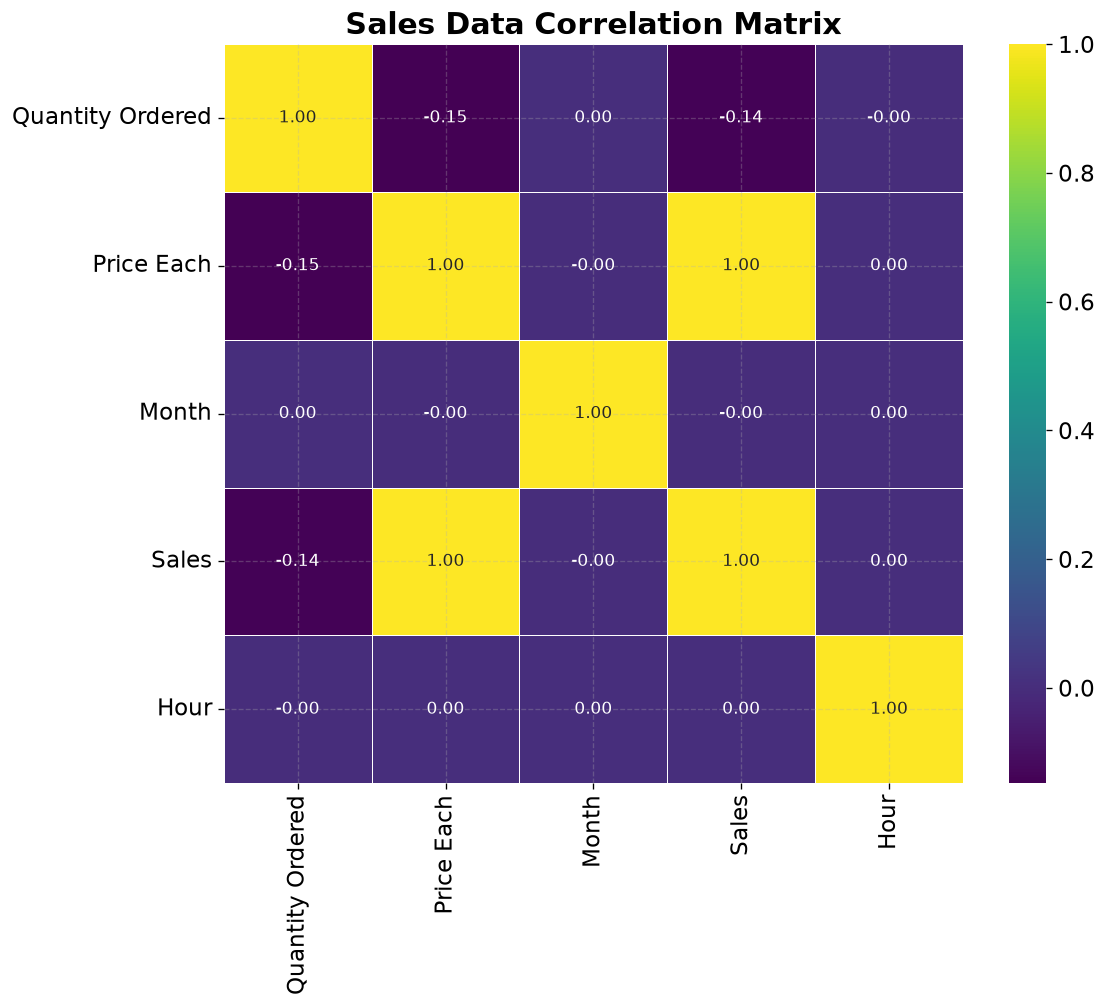

In [39]:
# Check correlation between numeric variables and visualise it using a heatmap
sales_corr = sales_model.drop(columns=["Product","City"])
correlation_matrix = sales_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.title('Sales Data Correlation Matrix')
plt.show()


* **Decision：** Will need to **remove Price Each** as mathematically it is perfectly positively correlated with Sales (Pearson correlation coefficient=1.00).

In [40]:
# Drop Price Each
sales_model = sales_model.drop(columns="Price Each")

### 5.3 Encode Categorical Variables

In [41]:
# Encode Product and City with One-hot encode as price differs by product and purchasing
# bahviour varies by city
sales_model = pd.get_dummies(
    sales_model,
    columns=["Product", "City"],
    drop_first=True
)

sales_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 30 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Quantity Ordered                    185950 non-null  int64  
 1   Month                               185950 non-null  int64  
 2   Sales                               185950 non-null  float64
 3   Hour                                185950 non-null  int64  
 4   Product_27in 4K Gaming Monitor      185950 non-null  bool   
 5   Product_27in FHD Monitor            185950 non-null  bool   
 6   Product_34in Ultrawide Monitor      185950 non-null  bool   
 7   Product_AA Batteries (4-pack)       185950 non-null  bool   
 8   Product_AAA Batteries (4-pack)      185950 non-null  bool   
 9   Product_Apple Airpods Headphones    185950 non-null  bool   
 10  Product_Bose SoundSport Headphones  185950 non-null  bool   
 11  Product_Flatscreen TV               1

### 5.4 Split the dataset (70% for training, 30% for testing)

In [42]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = sales_model.drop('Sales', axis=1) 
y = sales_model['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=88)

In [43]:
# Double check columns in training data
print(X_train.columns.tolist())

['Quantity Ordered', 'Month', 'Hour', 'Product_27in 4K Gaming Monitor', 'Product_27in FHD Monitor', 'Product_34in Ultrawide Monitor', 'Product_AA Batteries (4-pack)', 'Product_AAA Batteries (4-pack)', 'Product_Apple Airpods Headphones', 'Product_Bose SoundSport Headphones', 'Product_Flatscreen TV', 'Product_Google Phone', 'Product_LG Dryer', 'Product_LG Washing Machine', 'Product_Lightning Charging Cable', 'Product_Macbook Pro Laptop', 'Product_ThinkPad Laptop', 'Product_USB-C Charging Cable', 'Product_Vareebadd Phone', 'Product_Wired Headphones', 'Product_iPhone', 'City_ Austin', 'City_ Boston', 'City_ Dallas', 'City_ Los Angeles', 'City_ New York City', 'City_ Portland', 'City_ San Francisco', 'City_ Seattle']


### 5.5 Choose the algorithm, train and test the model

#### 5.5.1 Linear Regression

In [44]:
# Double check missing values in training set
missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_train

Series([], dtype: int64)

In [45]:
# Apply standardisation on continuous features

from sklearn.preprocessing import StandardScaler

# Continuous features to be standardised
continuous_features = [
    "Quantity Ordered",
    "Month",
    "Hour"
]

# Dummy variables (keep as 0/1)
dummy_features = [
    col for col in X_train.columns
    if col not in continuous_features
]

# Initialise scaler
scaler = StandardScaler()

# Fit scaler on training data only
X_train_scaled_cont = pd.DataFrame(
    scaler.fit_transform(X_train[continuous_features]),
    columns=continuous_features,
    index=X_train.index
)

# Apply same transformation to testing data
X_test_scaled_cont = pd.DataFrame(
    scaler.transform(X_test[continuous_features]),
    columns=continuous_features,
    index=X_test.index
)

# Combine scaled continuous features with dummy variables
X_train_scaled = pd.concat(
    [X_train_scaled_cont, X_train[dummy_features]],
    axis=1
)

X_test_scaled = pd.concat(
    [X_test_scaled_cont, X_test[dummy_features]],
    axis=1
)

# Keep original column order
X_train_scaled = X_train_scaled[X_train.columns]
X_test_scaled = X_test_scaled[X_test.columns]

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(130165, 29)
(55785, 29)


In [46]:
# Train a Linear Regression model to predict MaxTemp
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](29,)","[ 3.36,-0.05, 0.01,...,-0.14,-0.02,-0.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['Quantity Ordered','Month','Hour',...,'City_ Portland', 'City_ San Francisco','City_ Seattle']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,111.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,29


In [47]:
# Predict on testing set
sales_pred_lr = lr_model.predict(X_test_scaled)

#### 5.5.2 Random Forest

In [48]:
# Train a Random Forest model to predict MaxTemp
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

sales_pred_rf = rf_model.predict(X_test)

#### 5.5.3 Gradient Boosting

In [49]:
# Train a XGBoost model to predict Sales
from xgboost import XGBRegressor

# Train a XGBoost model to predict MaxTemp

xgb_model = XGBRegressor(
    n_estimators=200,
    random_state=42,
    enable_categorical=True
)

xgb_model.fit(X_train, y_train)

sales_pred_xgb = xgb_model.predict(X_test)

## 6. Evaluate and Visualize model Performance

### 6.1 Linear Regression

* **Mean Absolute Error (MAE) and R-squared (R²)**

In [50]:
# Evaluate the model's performance using Mean Absolute Error (MAE) 
# and R-squared (R²)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, sales_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, sales_pred_lr))
r2_lr = r2_score(y_test, sales_pred_lr)

print(f"MAE : {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²  : {r2_lr:.3f}")

MAE : 1.608
RMSE: 12.054
R²  : 0.999


* **Predicted v.s. Actual**

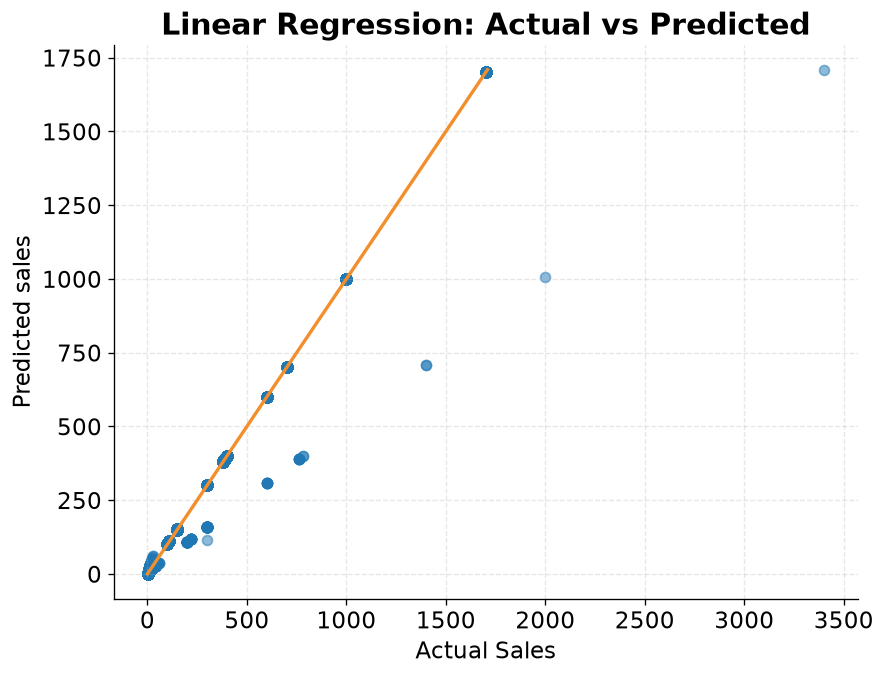

In [51]:
# Visualise the predicted vs actual MaxTemp values
plt.figure()
plt.scatter(y_test, sales_pred_lr, alpha=0.5)
plt.plot(
    [sales_pred_lr.min(), sales_pred_lr.max()],
    [sales_pred_lr.min(), sales_pred_lr.max()],
    color=ORANGE,
    linewidth=2
)
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel('Actual Sales')
plt.ylabel('Predicted sales')
plt.show()


* **Feature Importance**

In [52]:
coef_df_lr = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": lr_model.coef_
})

coef_df_lr = coef_df_lr.reindex(
    coef_df_lr["Coefficient"].abs().sort_values(ascending=False).index
)

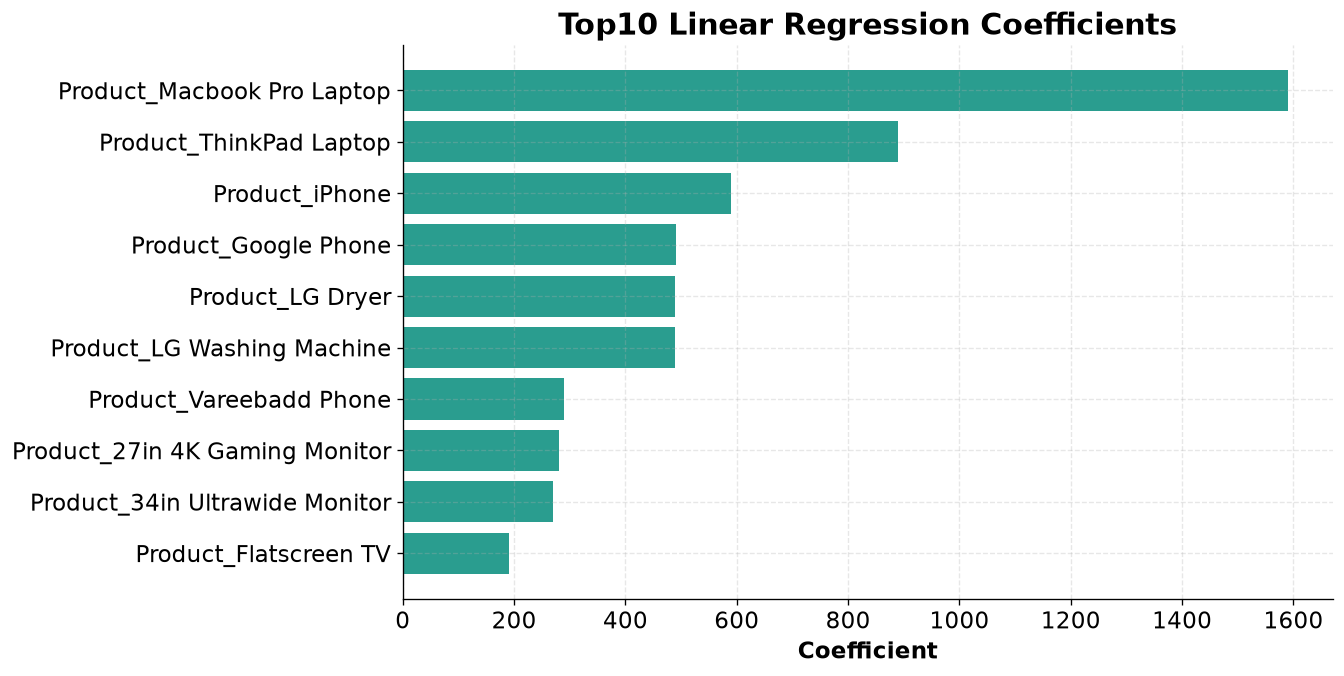

In [53]:
top_coef_lr = coef_df_lr.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_coef_lr["Feature"],
    top_coef_lr["Coefficient"],
    color=GREEN
)

plt.xlabel("Coefficient", fontsize=14, fontweight="bold")
plt.title("Top10 Linear Regression Coefficients")

plt.gca().invert_yaxis()

plt.show()

### 6.2 Random Forest

* **Mean Absolute Error (MAE) and R-squared (R²)**

In [54]:
# Evaluate the model's performance using Mean Absolute Error (MAE) 
# and R-squared (R²)
mae_rf = mean_absolute_error(y_test, sales_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, sales_pred_rf))
r2_rf = r2_score(y_test, sales_pred_rf)

print(f"MAE : {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²  : {r2_rf:.3f}")

MAE : 0.010
RMSE: 1.795
R²  : 1.000


* **Predicted v.s. Actual**

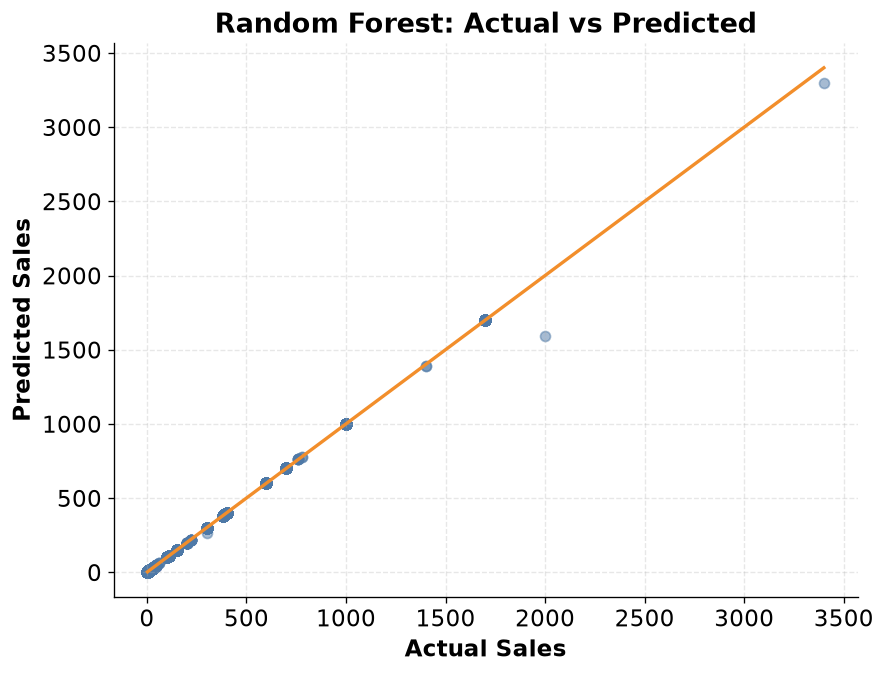

In [55]:
# Visualise the predicted vs actual sales

plt.figure()

plt.scatter(y_test, sales_pred_rf, color=PRIMARY, alpha=0.5)

# 45-degree reference line
min_val = min(y_test.min(), sales_pred_rf.min())
max_val = max(y_test.max(), sales_pred_rf.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color=ORANGE,
         linewidth=2)

plt.title("Random Forest: Actual vs Predicted", 
          fontsize=16, fontweight='bold')
plt.xlabel('Actual Sales', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Sales', fontsize=14, fontweight="bold")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

* **Feature Importance**

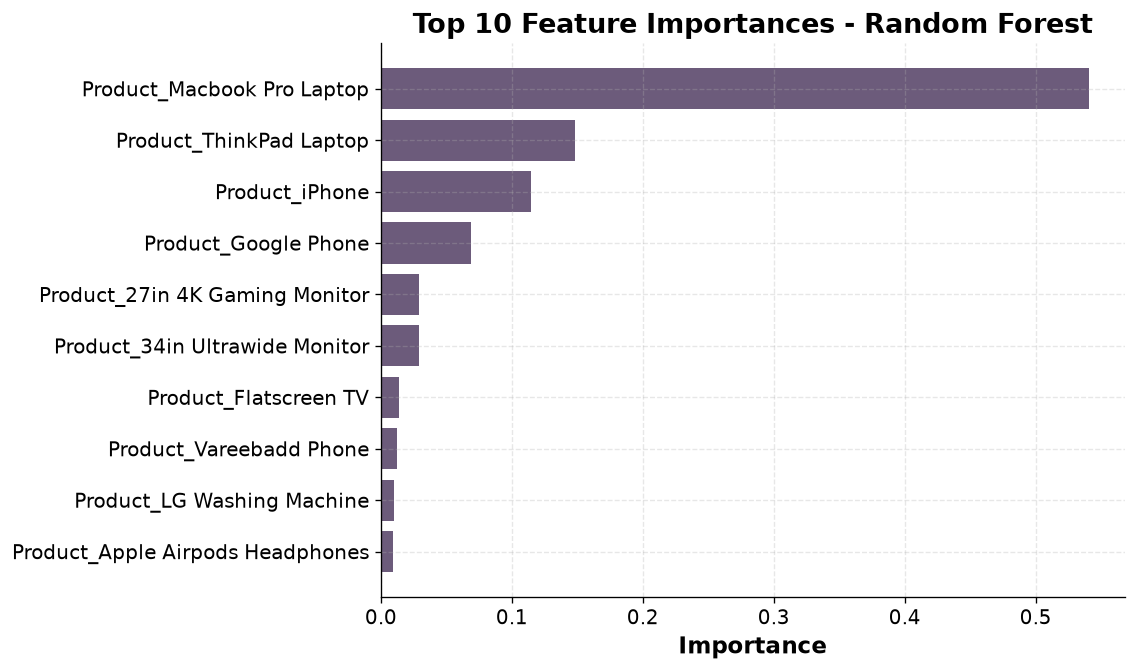

In [56]:
# Check feature importance of the Random Forest model
importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure()

plt.barh(
    importance_rf['Feature'],
    importance_rf['Importance'],
    color=ACCENT
)

plt.gca().invert_yaxis()

plt.title('Top 10 Feature Importances - Random Forest',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Importance', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

### 6.3 XGBoost

* **Mean Absolute Error (MAE) and R-squared (R²)**

In [57]:
# Evaluate the model's performance using Mean Absolute Error (MAE) 
# and R-squared (R²)
mae_xgb = mean_absolute_error(y_test, sales_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, sales_pred_xgb))
r2_xgb = r2_score(y_test, sales_pred_xgb)

print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")

MAE : 0.338
RMSE: 1.342
R²  : 1.000


* **Predicted v.s. Actual**

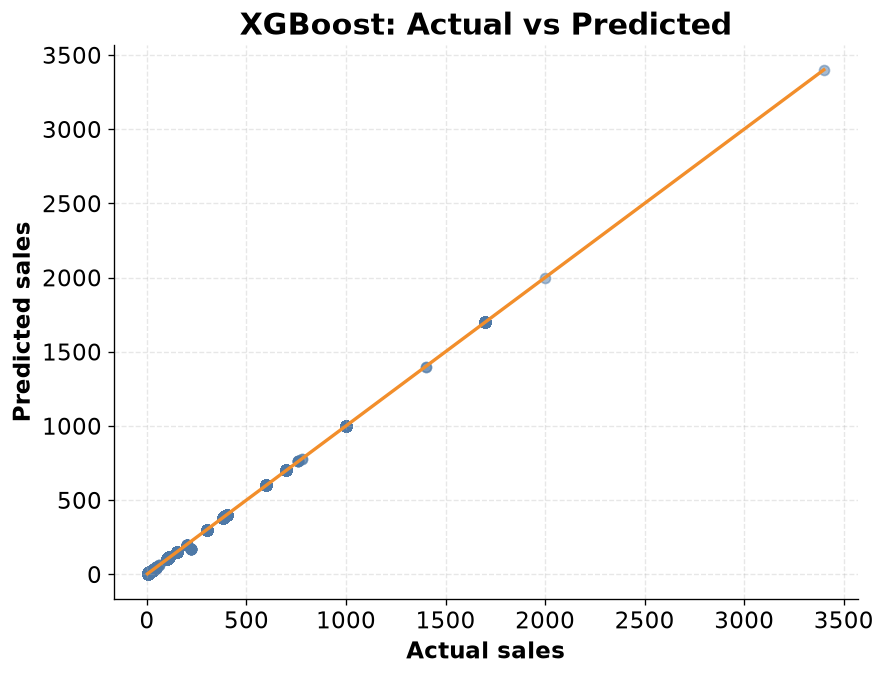

In [58]:
# Visualize the predicted vs actual sales
plt.figure()

plt.scatter(
    y_test,
    sales_pred_xgb,
    alpha=0.5,
    color=PRIMARY
)

# 45-degree reference line
min_val = min(y_test.min(), sales_pred_xgb.min())
max_val = max(y_test.max(), sales_pred_xgb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color=ORANGE,
    linewidth=2
)

plt.title(
    'XGBoost: Actual vs Predicted',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Actual sales', fontsize=14, fontweight='bold')
plt.ylabel('Predicted sales', fontsize=14, fontweight='bold')

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

* **Feature Importance**

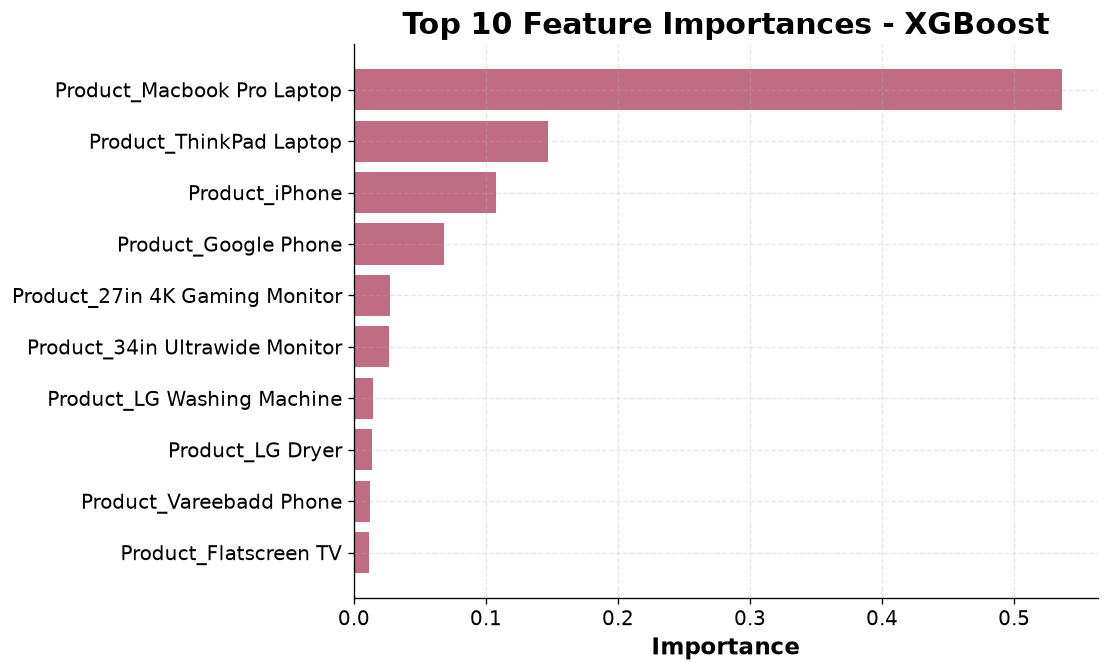

In [59]:
# Check feature importance of the XGBoost model
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure()

plt.barh(
    xgb_importance['Feature'],
    xgb_importance['Importance'],
    color=SECONDARY
)

plt.gca().invert_yaxis()

plt.title(
    'Top 10 Feature Importances - XGBoost',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Importance', fontsize=14,fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## Conclusion

### **7. Can machine learning models predict sales revenue accurately?**


All three models **predicted sales revenue accurately on this dataset.** Random Forest and XGBoost achieved an $R^2$ close to 1.000 and lower errors than Linear Regression. However, this strong performance is partly due to the relatively simple dataset structure, particularly the close relationship between product identity and product price. Performance may be lower in real-world applications involving more complex customer, promotional, and market factors.

### **8. Which features are most important in predicting sales?**

**Product-related features were the most influential predictors** across all three models. High-priced products, particularly the MacBook Pro Laptop, ThinkPad Laptop, iPhone, and Google Phone, showed the largest coefficients or feature-importance scores. This is because each product has a fixed price in the dataset, meaning that product identity contains substantial information about the expected sales value.

Other features such as city, month, and hour contributed relatively little to transaction-level sales predictions.